# Running Analysis
Reads Coros `.fit` files, filters to running activities only, and computes personal records.

## 0 · Dependencies

In [2]:
# Install if needed (comment out after first run)
# %pip install fitdecode pandas numpy

In [3]:
import glob
import warnings

import fitdecode
import numpy as np
import pandas as pd

# Cell: imports for plotting
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np

from run_analyzer import (
    RunAnalyzer, PR_TARGETS, RUNNING_SPORT_TYPES,
    dist, climb, descent,           # target constructors
    DistanceTarget, ElevationTarget, # types, if you need isinstance checks
)

warnings.filterwarnings("ignore")

## 1 · Discover files

In [ ]:
files = glob.glob("../data/coros/*.fit")
print(f"Detected {len(files)} FIT files")

Detected 1 FIT files


## 2 · Parse FIT files → DataFrames

Uses `fitdecode` exclusively (more tolerant of Coros FIT quirks than fitparse).  
Two-pass approach: first reads the `session` frame to get sport type, then reads `record` frames for sensor data.  
Non-running activities (cycling, swimming, strength, …) are skipped after pass 1 with no data loaded.

In [5]:
def parse_fit_file(path: str) -> tuple[pd.DataFrame | None, str | None]:
    """
    Parse a single Coros FIT file using fitdecode.

    Strategy (mirrors your working approach):
      1. First pass: read the 'session' frame to get sport type.
         If it's not a running activity → return (None, sport) immediately.
      2. Second pass: collect all 'record' frames into a DataFrame.

    Returns
    -------
    (DataFrame, sport)  – running activity, data ready
    (None, sport)       – non-running activity, intentionally skipped
    (None, None)        – unreadable / no records found
    """
    # --- Pass 1: identify sport from session frame ---
    sport: str | None = None
    try:
        with fitdecode.FitReader(path) as fit:
            for frame in fit:
                if (
                    frame.frame_type == fitdecode.FIT_FRAME_DATA
                    and frame.name == "session"
                ):
                    raw = frame.get_value("sport")
                    if raw is not None:
                        sport = str(raw).lower().replace(" ", "_")
                    break  # only need the first session frame
    except Exception as exc:
        print(f"  [WARN] Could not read session from {path}: {exc}")
        return None, None

    if sport is not None and sport not in RUNNING_SPORT_TYPES:
        return None, sport

    # --- Pass 2: read record frames ---
    records: list[dict] = []
    try:
        with fitdecode.FitReader(path) as fit:
            for frame in fit:
                if (
                    frame.frame_type == fitdecode.FIT_FRAME_DATA
                    and frame.name == "record"
                ):
                    row = {field.name: field.value for field in frame.fields}
                    records.append(row)
    except Exception as exc:
        print(f"  [WARN] Could not read records from {path}: {exc}")
        return None, None

    if not records:
        return None, sport

    df = pd.DataFrame(records)

    # fitdecode already converts semicircles → degrees for lat/long,
    # but guard in case it doesn't (large int values are a giveaway)
    for col in ("position_lat", "position_long"):
        if col in df.columns:
            numeric = pd.to_numeric(df[col], errors="coerce")
            if numeric.abs().max() > 180:
                df[col] = numeric * (180 / 2**31)

    return df, sport


# ---------------------------------------------------------------------------
# Load all files
# ---------------------------------------------------------------------------
runs: list[pd.DataFrame] = []
run_paths: list[str] = []
skipped: dict[str, int] = {}

for path in sorted(files):
    df, sport = parse_fit_file(path)
    if df is not None:
        runs.append(df)
        run_paths.append(path)
    else:
        label = sport or "unknown/corrupt"
        skipped[label] = skipped.get(label, 0) + 1

print(f"Loaded  : {len(runs)} running activities")
if skipped:
    print("Skipped :", ", ".join(f"{v}× {k}" for k, v in sorted(skipped.items())))

Loaded  : 1 running activities


## 3 · Quick sanity check on raw data

In [6]:
if runs:
    print("Columns in a sample run:")
    print(runs[0].dtypes)
    print()
    print("First few rows:")
    display(runs[0].head())

Columns in a sample run:
activity_type                        object
timestamp               datetime64[ns, UTC]
distance                            float64
position_lat                        float64
position_long                       float64
heart_rate                          float64
enhanced_speed                      float64
speed                               float64
step_length                         float64
Effort Pace                         float64
cadence                             float64
power                               float64
accumulated_power                   float64
enhanced_altitude                   float64
altitude                            float64
stance_time                         float64
stance_time_balance                 float64
vertical_oscillation                float64
vertical_ratio                      float64
dtype: object

First few rows:


,activity_type,timestamp,distance,position_lat,position_long,heart_rate,enhanced_speed,speed,step_length,Effort Pace,cadence,power,accumulated_power,enhanced_altitude,altitude,stance_time,stance_time_balance,vertical_oscillation,vertical_ratio
0,running,2026-05-14 16:03:30+00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,running,2026-05-14 16:03:31+00:00,0.0,28.763293,-17.896033,96.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,running,2026-05-14 16:03:32+00:00,0.0,28.763284,-17.896028,95.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,running,2026-05-14 16:03:33+00:00,0.0,28.763274,-17.896024,95.0,1.419,1.419,300.0,1.419,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,running,2026-05-14 16:03:34+00:00,0.0,28.763289,-17.896012,95.0,1.561,1.561,0.0,1.561,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4 · Build the analyzer

In [7]:
analyzer = RunAnalyzer(runs)
print(analyzer)

RunAnalyzer(1 runs, 0 flagged)


## 5 · All runs summary

In [8]:
summary = analyzer.summary()
display(summary)

,id,date,distance_km,time,avg_pace,avg_hr,avg_cadence,elev_gain_m,elev_loss_m,flagged
0,0,2026-05-14,12.19,2:00:10,9:52 /km,152,76,25145,22999,False


## 6 · Flag runs with GPS anomalies

Use any of the methods below.  
Flagged runs are **excluded from all PR calculations** but remain in the summary table (shown as `flagged=True`).

In [ ]:
# --- Option A: flag by run index ---
# analyzer.flag(0, 3)          # flag runs #0 and #3

# --- Option B: flag by date (flags ALL runs that day) ---
analyzer.flag_by_date("2025-09-27")
analyzer.flag_by_date("2024-12-28")
analyzer.flag_by_date("2025-01-12")
analyzer.flag_by_date("2025-04-05")

# --- Unflag if you change your mind ---
# analyzer.unflag(3)

# --- See what's currently flagged ---
print("Flagged run IDs:", analyzer.flagged)
display(analyzer.summary()[analyzer.summary()["flagged"]])

Flagged run IDs: set()


,id,date,distance_km,time,avg_pace,avg_hr,avg_cadence,elev_gain_m,elev_loss_m,flagged


## 7 · Configure PR targets

Edit this cell to enable/disable targets or add your own.  
`dist(label, km)` · `climb(label, m)` · `descent(label, m)`

In [11]:
# ── Full target list from run_analyzer.py ──────────────────────────────────
# PR_TARGETS already contains all distances + elevation targets.
# Reassign this variable to customise what gets computed.

MY_TARGETS = PR_TARGETS  # use everything

# ── Examples: override with a subset ───────────────────────────────────────
# MY_TARGETS = [
#     dist("400m",       0.400),
#     dist("1 km",       1.0),
#     dist("5 km",       5.0),
#     dist("10 km",      10.0),
#     dist("½ marathon", 21.0975),
#     dist("marathon",   42.195),
#     climb("+VK",       1000),
#     climb("+2VK",      2000),
#     descent("-VK",     1000),
# ]

# ── Add a completely custom target ─────────────────────────────────────────
# MY_TARGETS = PR_TARGETS + [dist("100 km", 100.0), climb("+3000 m", 3000)]

print(f"Active targets: {len(MY_TARGETS)} "
      f"({sum(1 for t in MY_TARGETS if t.kind == 'distance')} distance, "
      f"{sum(1 for t in MY_TARGETS if t.kind == 'elevation')} elevation)")

Active targets: 26 (14 distance, 12 elevation)


## 8 · Personal Records

In [12]:
prs = analyzer.pr_table(MY_TARGETS)

# ── Distance PRs ────────────────────────────────────────────────────────────
print("━" * 55)
print("  DISTANCE PERSONAL RECORDS")
print("━" * 55)
dist_prs = prs[prs["kind"] == "distance"][["label", "target", "time", "pace", "date", "run_id"]]
display(dist_prs.reset_index(drop=True))

# ── Elevation PRs ───────────────────────────────────────────────────────────
print()
print("━" * 55)
print("  ELEVATION PERSONAL RECORDS")
print("━" * 55)
elev_prs = prs[prs["kind"] == "elevation"][["label", "target", "time", "m_h", "date", "run_id"]]
display(elev_prs.reset_index(drop=True))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DISTANCE PERSONAL RECORDS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,label,target,time,pace,date,run_id
0,400m,0.4 km,1:07,2:47 /km,2026-02-22,162.0
1,½ mile,0.8047 km,2:46,3:26 /km,2026-02-01,148.0
2,1 km,1 km,3:35,3:35 /km,2025-12-21,122.0
3,1 mile,1.609 km,5:51,3:38 /km,2026-01-08,131.0
4,2 miles,3.219 km,12:17,3:49 /km,2026-01-08,131.0
5,5 km,5 km,20:34,4:07 /km,2026-04-06,193.0
6,10 km,10 km,41:35,4:10 /km,2026-04-06,193.0
7,15 km,15 km,1:13:19,4:53 /km,2025-12-29,127.0
8,10 miles,16.09 km,1:19:08,4:55 /km,2025-12-29,127.0
9,20 km,20 km,1:39:03,4:57 /km,2026-03-05,171.0



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ELEVATION PERSONAL RECORDS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,label,target,time,m_h,date,run_id
0,+100 m,100 m gain,4:12,1429 m/h,2026-03-29,187.0
1,+300 m,300 m gain,14:19,1257 m/h,2026-03-29,187.0
2,+500 m,500 m gain,25:26,1180 m/h,2026-03-29,187.0
3,+VK,1000 m gain,55:04,1090 m/h,2026-03-29,187.0
4,+1500 m,1500 m gain,1:59:13,755 m/h,2026-02-21,161.0
5,+2VK,2000 m gain,2:52:58,694 m/h,2026-02-21,161.0
6,-100 m,100 m loss,1:34,3830 m/h,2026-01-02,128.0
7,-300 m,300 m loss,6:19,2850 m/h,2026-02-26,165.0
8,-500 m,500 m loss,11:32,2601 m/h,2026-02-26,165.0
9,-VK,1000 m loss,31:39,1896 m/h,2026-02-15,157.0


In [13]:
# ── Drill into any single target by label ──────────────────────────────────
for label in ["5 km", "+VK", "-VK"]:
    pr = analyzer.best_for(label)
    if pr:
        extra = pr.get('pace') or pr.get('mh', '—')
        print(f"{label:<12s}  {pr['time']:>9s}  {extra:>12s}  {pr['date']}  [run #{pr['run_id']}]")
    else:
        print(f"{label:<12s}  — (no qualifying run)")

5 km              20:34      4:07 /km  2026-04-06  [run #193]
+VK               55:04      1090 m/h  2026-03-29  [run #187]
-VK               31:39      1896 m/h  2026-02-15  [run #157]


In [14]:
# Cell: shared plot style
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e8e8e8",
    "grid.linestyle":    "-",
    "font.family":       "sans-serif",
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})

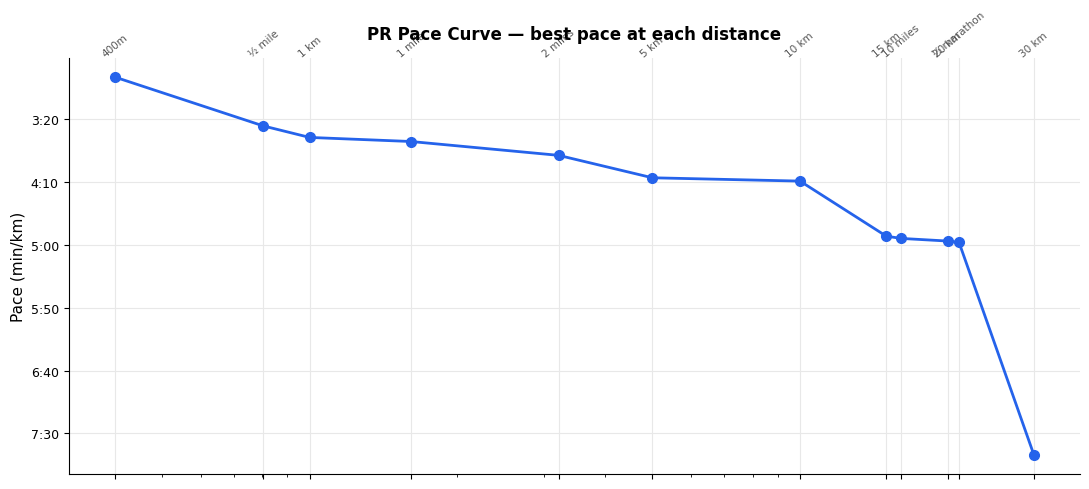

In [15]:
# Cell: PR pace curve — distance (x) vs best pace (y)
prs = analyzer.personal_records(MY_TARGETS)

# Only distance PRs that have a result
dist_targets = [t for t in MY_TARGETS if isinstance(t, DistanceTarget)]
points = []
for t in dist_targets:
    pr = prs.get(t.label)
    if pr:
        pace_secs = pr["time_s"] / t.distance_km   # secs/km
        points.append((t.distance_km, pace_secs, t.label, pr["date"]))

points.sort(key=lambda x: x[0])
xs   = [p[0] for p in points]
ys   = [p[1] for p in points]
lbls = [p[2] for p in points]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(xs, ys, "o-", color="#2563EB", lw=2, ms=7, zorder=3)

# Y-axis: seconds → M:SS labels
def secs_to_mss(val, _):
    m, s = divmod(int(val), 60)
    return f"{m}:{s:02d}"

ax.yaxis.set_major_formatter(mticker.FuncFormatter(secs_to_mss))
ax.invert_yaxis()   # faster pace (lower secs) at top

# X-axis: log scale so short distances aren't squashed
ax.set_xscale("log")
ax.set_xticks(xs)
ax.set_xticklabels(lbls, rotation=40, ha="right", fontsize=8)
ax.xaxis.set_major_formatter(mticker.NullFormatter())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
# Label each tick manually
for x, lbl in zip(xs, lbls):
    ax.text(x, ax.get_ylim()[1], lbl, ha="center", va="bottom",
            fontsize=7.5, rotation=40, color="#555")

ax.set_ylabel("Pace (min/km)")
ax.set_title("PR Pace Curve — best pace at each distance", fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

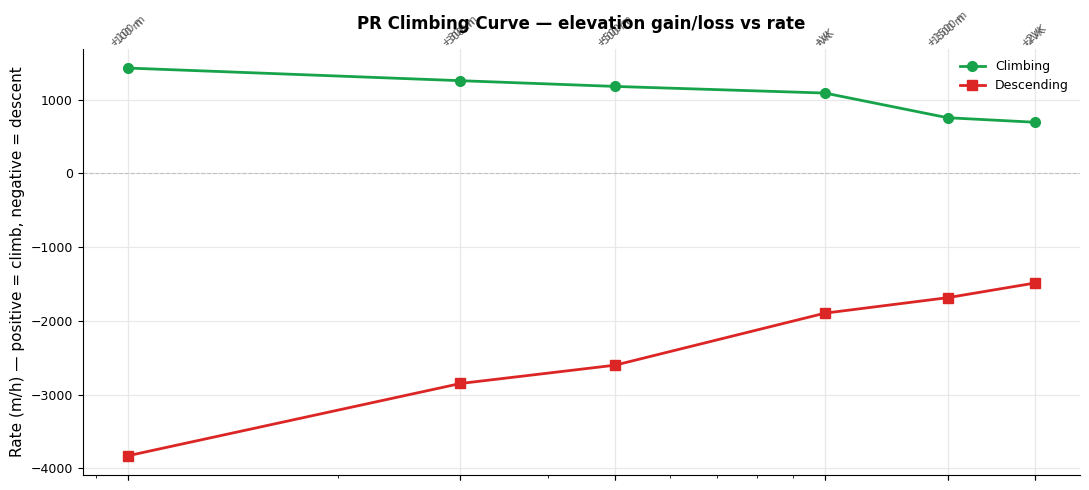

In [56]:

# Cell: PR climbing curve — elevation (x) vs climbing/descending rate (y)
prs = analyzer.personal_records(MY_TARGETS)

# Only elevation PRs that have a result
elev_targets = [t for t in MY_TARGETS if isinstance(t, ElevationTarget)]
climb_points = []
for t in elev_targets:
    pr = prs.get(t.label)
    if pr:
        rate_mh = t.elev_m / (pr["time_s"] / 3600)  # m/h
        # Multiply by -1 for descending so it appears negative
        if t.direction == "loss":
            rate_mh = -rate_mh
        climb_points.append((t.elev_m, rate_mh, t.label, pr["date"], t.direction))

if climb_points:
    # Separate climb and descent points
    climb_only = [p for p in climb_points if p[4] == "gain"]
    descent_only = [p for p in climb_points if p[4] == "loss"]

    fig, ax = plt.subplots(figsize=(11, 5))

    # Plot climbing (green)
    if climb_only:
        climb_only.sort(key=lambda x: x[0])
        xs_climb = [p[0] for p in climb_only]
        ys_climb = [p[1] for p in climb_only]
        lbls_climb = [p[2] for p in climb_only]
        ax.plot(xs_climb, ys_climb, "o-", color="#16A34A", lw=2, ms=7, zorder=3, label="Climbing")

    # Plot descending (red, negative rates)
    if descent_only:
        descent_only.sort(key=lambda x: x[0])
        xs_descent = [p[0] for p in descent_only]
        ys_descent = [p[1] for p in descent_only]
        lbls_descent = [p[2] for p in descent_only]
        ax.plot(xs_descent, ys_descent, "s-", color="#DC2626", lw=2, ms=7, zorder=3, label="Descending")

    # X-axis: log scale for elevation
    all_labels = [p[2] for p in climb_points]
    all_xs = [p[0] for p in climb_points]
    ax.set_xscale("log")
    ax.set_xticks(all_xs)
    ax.set_xticklabels(all_labels, rotation=40, ha="right", fontsize=8)
    ax.xaxis.set_major_formatter(mticker.NullFormatter())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    
    # Label each tick manually
    for x, lbl in zip(all_xs, all_labels):
        ax.text(x, ax.get_ylim()[1], lbl, ha="center", va="bottom",
                fontsize=7.5, rotation=40, color="#555")

    # Add horizontal line at 0
    ax.axhline(0, color="#999", lw=0.8, linestyle="--", alpha=0.5)

    ax.set_ylabel("Rate (m/h) — positive = climb, negative = descent")
    ax.set_title("PR Climbing Curve — elevation gain/loss vs rate", fontweight="bold", pad=14)
    ax.legend(frameon=False, loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No elevation PRs yet — need runs with altitude data.")


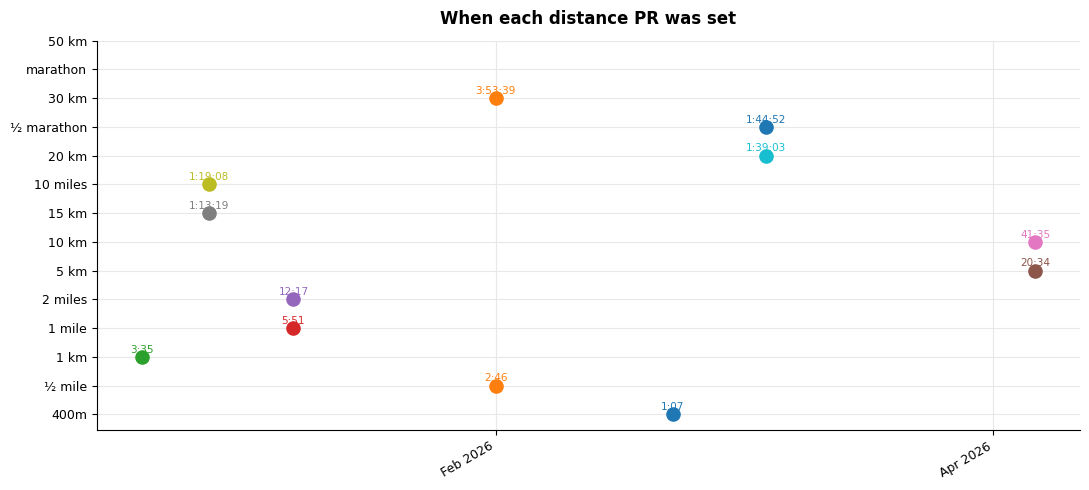

In [16]:
# Cell: PR timeline — when each distance PR was set
from matplotlib.cm import get_cmap

fig, ax = plt.subplots(figsize=(11, 5))
cmap = get_cmap("tab10")

dist_targets_sorted = sorted(
    [t for t in MY_TARGETS if isinstance(t, DistanceTarget)],
    key=lambda t: t.distance_km
)

for i, t in enumerate(dist_targets_sorted):
    pr = prs.get(t.label)
    if pr and pr["date"]:
        ax.scatter(pr["date"], i, color=cmap(i % 10), s=90, zorder=3)
        ax.text(pr["date"], i + 0.15, pr["time"], fontsize=7.5,
                ha="center", color=cmap(i % 10))

ax.set_yticks(range(len(dist_targets_sorted)))
ax.set_yticklabels([t.label for t in dist_targets_sorted])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30, ha="right")
ax.set_title("When each distance PR was set", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

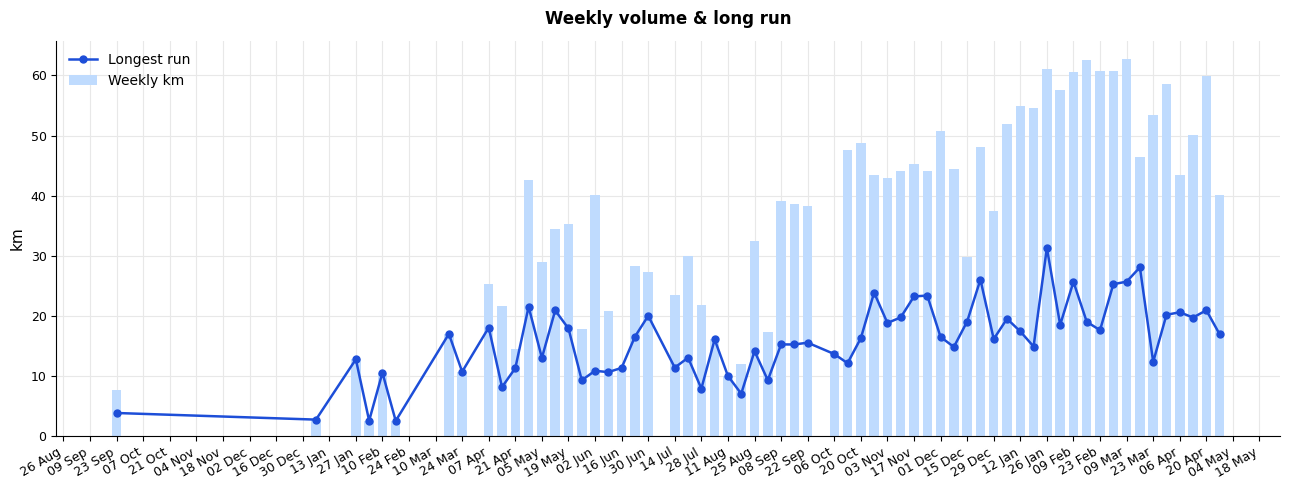

In [17]:
# Cell: weekly km volume + longest run of the week
df_sum = analyzer.summary(include_flagged=False).copy()
df_sum["date"] = pd.to_datetime(df_sum["date"])
df_sum["week"] = df_sum["date"].dt.to_period("W").apply(lambda p: p.start_time)

weekly = (
    df_sum.groupby("week")
    .agg(total_km=("distance_km", "sum"), long_run=("distance_km", "max"), runs=("id", "count"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(weekly["week"], weekly["total_km"], width=5, color="#BFDBFE",
       label="Weekly km", zorder=2)
ax.plot(weekly["week"], weekly["long_run"], "o-", color="#1D4ED8",
        lw=1.8, ms=5, label="Longest run", zorder=3)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.xticks(rotation=30, ha="right")
ax.set_ylabel("km")
ax.legend(frameon=False)
ax.set_title("Weekly volume & long run", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

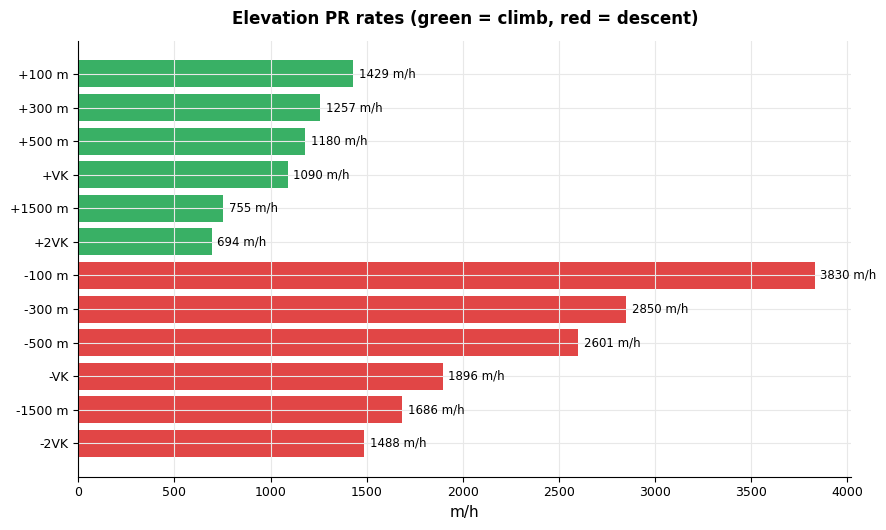

In [18]:
# Cell: elevation PR rates (m/h)
elev_targets = [t for t in MY_TARGETS if isinstance(t, ElevationTarget)]
elev_points = []
for t in elev_targets:
    pr = prs.get(t.label)
    if pr:
        rate = t.elev_m / (pr["time_s"] / 3600)
        elev_points.append((t.label, rate, t.direction))

if elev_points:
    labels_e = [p[0] for p in elev_points]
    rates    = [p[1] for p in elev_points]
    colors   = ["#16A34A" if p[2] == "gain" else "#DC2626" for p in elev_points]

    fig, ax = plt.subplots(figsize=(9, max(4, len(elev_points) * 0.45)))
    bars = ax.barh(labels_e, rates, color=colors, alpha=0.85)
    ax.bar_label(bars, fmt="%.0f m/h", padding=4, fontsize=8.5)
    ax.set_xlabel("m/h")
    ax.set_title("Elevation PR rates (green = climb, red = descent)", fontweight="bold", pad=12)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No elevation PRs yet — need runs with altitude data.")

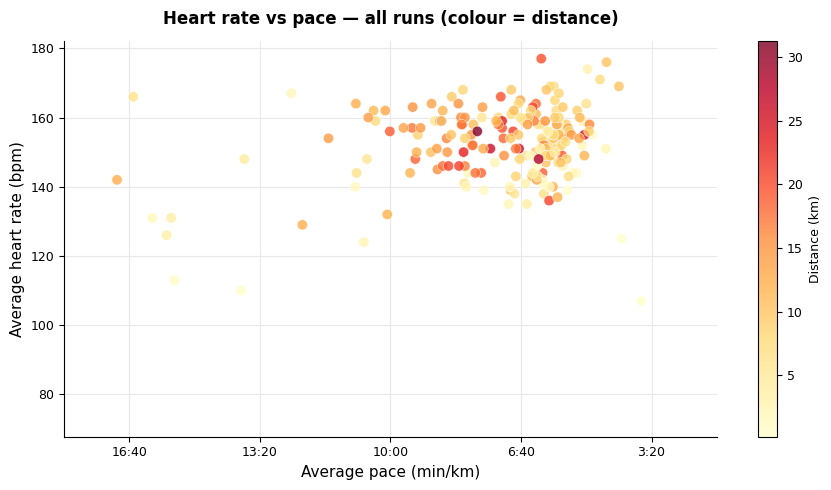

In [33]:
# Cell: heart rate vs pace scatter — one point per run
df_sum = analyzer.summary(include_flagged=False).copy()

# Convert avg_pace string "M:SS /km" back to float seconds
def pace_str_to_secs(s):
    try:
        parts = s.replace(" /km", "").split(":")
        return int(parts[0]) * 60 + int(parts[1])
    except Exception:
        return np.nan

df_sum["pace_secs"] = df_sum["avg_pace"].apply(pace_str_to_secs)
df_plot = df_sum.dropna(subset=["avg_hr", "pace_secs"])

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    df_plot["pace_secs"], df_plot["avg_hr"],
    c=df_plot["distance_km"], cmap="YlOrRd",
    s=55, alpha=0.8, edgecolors="white", lw=0.4, zorder=3
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Distance (km)", fontsize=9)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(secs_to_mss))
ax.set_xlabel("Average pace (min/km)")
ax.set_ylabel("Average heart rate (bpm)")
ax.set_xlim(100, 1100)
ax.invert_xaxis()   # faster pace on the right
ax.set_title("Heart rate vs pace — all runs (colour = distance)", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

In [34]:
# ── Section 9: Setup ────────────────────────────────────────────────────────
# Run once. All plots below depend on this.

import seaborn as sns
from scipy.interpolate import interp1d
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm
import calendar
from datetime import timedelta

# Shared summary (no flagged runs)
df_all = analyzer.summary(include_flagged=False).copy()
df_all["date"] = pd.to_datetime(df_all["date"])

def pace_str_to_secs(s):
    try:
        return int(s.split(":")[0]) * 60 + int(s.split(":")[1].split(" ")[0])
    except Exception:
        return np.nan

def secs_to_mss(val, _=None):
    if np.isnan(val): return ""
    m, s = divmod(int(val), 60)
    return f"{m}:{s:02d}"

df_all["pace_secs"] = df_all["avg_pace"].apply(pace_str_to_secs)

# Pre-compute PRs once (reused across all cells)
prs      = analyzer.personal_records(MY_TARGETS)
pr_table = analyzer.pr_table(MY_TARGETS)

print(f"Ready: {len(df_all)} runs loaded for plotting")

Ready: 215 runs loaded for plotting


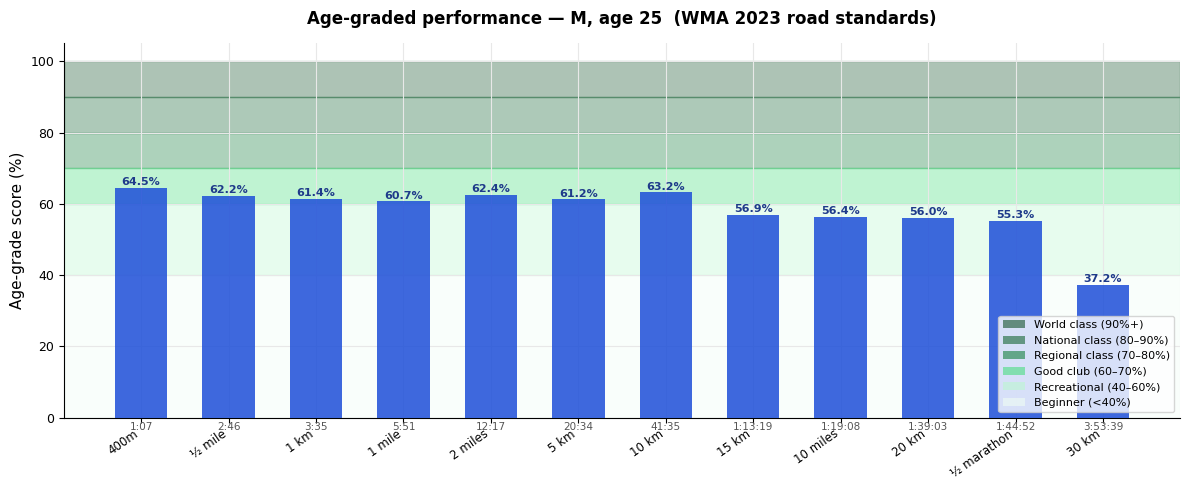

In [49]:
# ── Plot 6: Age-graded score per distance ──────────────────────────────────
# Scores your PRs against WMA 2023 open road standards.
# 100% = world-record equivalent for your age/sex.
# Zones: >90% world class · >80% national class · >70% regional · >60% good local

# ── CONFIG: set your details ───────────────────────────────────────────────
ATHLETE_AGE = 25        # your current age
ATHLETE_SEX = "M"       # "M" or "F"
# ──────────────────────────────────────────────────────────────────────────

# WMA 2023 open road standards (seconds) — world-record level baseline
_WMA_OPEN = {
    "M": {
        0.400:    43.03,
        1.0:     131.96,
        1.60934: 213.00,
        3.21869: 460.00,
        5.0:     756.00,
        10.0:   1577.00,
        15.0:   2504.00,
        16.0934:2677.00,
        20.0:   3330.00,
        21.0975:3481.00,
        30.0:   5220.00,
        42.195: 7299.00,
        50.0:   8939.00,
    },
    "F": {
        0.400:    47.60,
        1.0:     149.00,
        1.60934: 252.56,
        3.21869: 537.00,
        5.0:     851.00,
        10.0:   1762.00,
        15.0:   2798.00,
        16.0934:2993.00,
        20.0:   3770.00,
        21.0975:3995.00,
        30.0:   6180.00,
        42.195: 8125.00,
        50.0:  10260.00,
    },
}

# WMA age factors for road running (multiply open standard to get age standard)
# Factors < 1 mean the age group is slower → standard time is larger
# Derived from WMA 2023 tables, interpolated for intermediate ages
_WMA_AGE_FACTORS_M = {
    20: 1.000, 25: 1.000, 30: 1.000, 35: 1.007, 40: 1.023,
    45: 1.044, 50: 1.073, 55: 1.107, 60: 1.155, 65: 1.218,
    70: 1.302, 75: 1.418, 80: 1.582, 85: 1.820, 90: 2.200,
}
_WMA_AGE_FACTORS_F = {
    20: 1.000, 25: 1.000, 30: 1.000, 35: 1.008, 40: 1.025,
    45: 1.050, 50: 1.082, 55: 1.122, 60: 1.175, 65: 1.248,
    70: 1.348, 75: 1.490, 80: 1.700, 85: 1.990, 90: 2.450,
}

def _age_factor(age: int, sex: str) -> float:
    table = _WMA_AGE_FACTORS_M if sex == "M" else _WMA_AGE_FACTORS_F
    ages  = np.array(sorted(table.keys()))
    facts = np.array([table[a] for a in ages])
    return float(np.interp(age, ages, facts))

def age_grade(time_s: float, dist_km: float, age: int, sex: str) -> float | None:
    """Returns age-grade % (0–100). None if distance not in WMA table."""
    standards = _WMA_OPEN[sex]
    dists = np.array(sorted(standards.keys()))
    if dist_km < dists.min() * 0.95 or dist_km > dists.max() * 1.05:
        return None
    open_std = float(np.interp(dist_km, dists, [standards[d] for d in dists]))
    age_std  = open_std * _age_factor(age, sex)
    return min(100.0, (age_std / time_s) * 100)

# Compute scores
ag_points = []
for t in MY_TARGETS:
    if not isinstance(t, DistanceTarget):
        continue
    pr = prs.get(t.label)
    if not pr:
        continue
    score = age_grade(pr["time_s"], t.distance_km, ATHLETE_AGE, ATHLETE_SEX)
    if score:
        ag_points.append((t.label, t.distance_km, score, pr["time"]))

ag_points.sort(key=lambda x: x[1])
labels_ag = [p[0] for p in ag_points]
scores    = [p[2] for p in ag_points]
times_ag  = [p[3] for p in ag_points]

# Zone bands
zones = [
    (90, 100, "#14532d", "World class (90%+)"),
    (80,  90, "#166534", "National class (80–90%)"),
    (70,  80, "#15803d", "Regional class (70–80%)"),
    (60,  70, "#4ade80", "Good club (60–70%)"),
    (40,  60, "#bbf7d0", "Recreational (40–60%)"),
    ( 0,  40, "#f0fdf4", "Beginner (<40%)"),
]

fig, ax = plt.subplots(figsize=(12, 5))
for lo, hi, color, _ in zones:
    ax.axhspan(lo, hi, color=color, alpha=0.35, zorder=0)

x_pos = range(len(labels_ag))
bars  = ax.bar(x_pos, scores, color="#1D4ED8", alpha=0.85, zorder=3, width=0.6)

for i, (score, t) in enumerate(zip(scores, times_ag)):
    ax.text(i, score + 0.8, f"{score:.1f}%", ha="center", fontsize=8, fontweight="bold", color="#1e3a8a")
    ax.text(i, -3.5, t, ha="center", fontsize=7.5, color="#555", rotation=0)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels_ag, rotation=35, ha="right", fontsize=8.5)
ax.set_ylim(0, 105)
ax.set_ylabel("Age-grade score (%)")
ax.set_title(
    f"Age-graded performance — {ATHLETE_SEX}, age {ATHLETE_AGE}  (WMA 2023 road standards)",
    fontweight="bold", pad=14
)

legend_patches = [Patch(facecolor=c, alpha=0.6, label=lbl) for _, _, c, lbl in zones]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8, frameon=True)
plt.tight_layout()
plt.show()

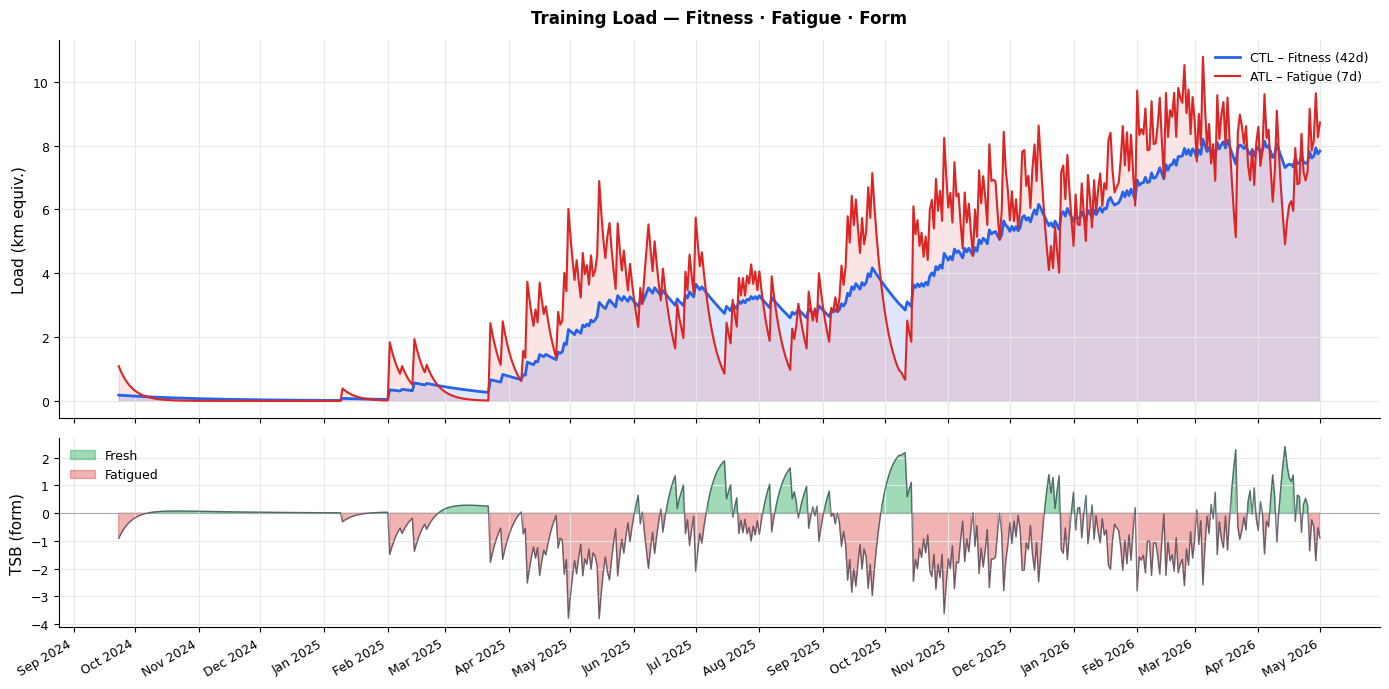

In [50]:
# ── Plot 7: Chronic & Acute Training Load + Form (TSB) ─────────────────────
# CTL (fitness)  = 42-day EWA of daily load
# ATL (fatigue)  = 7-day EWA of daily load
# TSB (form)     = CTL - ATL  (positive = fresh, negative = fatigued)
# Load proxy     = distance_km  (swap for hrTSS if you have HR data)

df_load = df_all[["date", "distance_km"]].copy()

# Build a full daily series (fill rest days with 0)
date_range = pd.date_range(df_load["date"].min(), df_load["date"].max(), freq="D")
daily = df_load.groupby("date")["distance_km"].sum().reindex(date_range, fill_value=0)

ctl_arr, atl_arr, tsb_arr = [], [], []
ctl, atl = 0.0, 0.0
for load in daily.values:
    ctl = ctl * (1 - 1/42) + load * (1/42)
    atl = atl * (1 - 1/7)  + load * (1/7)
    ctl_arr.append(ctl)
    atl_arr.append(atl)
    tsb_arr.append(ctl - atl)

dates_d = daily.index

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# Top panel: CTL & ATL
ax1.fill_between(dates_d, ctl_arr, alpha=0.15, color="#2563EB")
ax1.plot(dates_d, ctl_arr, color="#2563EB", lw=2, label="CTL – Fitness (42d)")
ax1.fill_between(dates_d, atl_arr, alpha=0.12, color="#DC2626")
ax1.plot(dates_d, atl_arr, color="#DC2626", lw=1.5, label="ATL – Fatigue (7d)")
ax1.set_ylabel("Load (km equiv.)")
ax1.legend(frameon=False, fontsize=9)
ax1.set_title("Training Load — Fitness · Fatigue · Form", fontweight="bold", pad=12)

# Bottom panel: TSB (form)
tsb_arr_np = np.array(tsb_arr)
ax2.axhline(0, color="#aaa", lw=0.8)
ax2.fill_between(dates_d, tsb_arr_np,
                 where=tsb_arr_np >= 0, color="#16A34A", alpha=0.4, label="Fresh")
ax2.fill_between(dates_d, tsb_arr_np,
                 where=tsb_arr_np <  0, color="#DC2626", alpha=0.35, label="Fatigued")
ax2.plot(dates_d, tsb_arr_np, color="#374151", lw=1, alpha=0.7)
ax2.set_ylabel("TSB (form)")
ax2.legend(frameon=False, fontsize=9)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

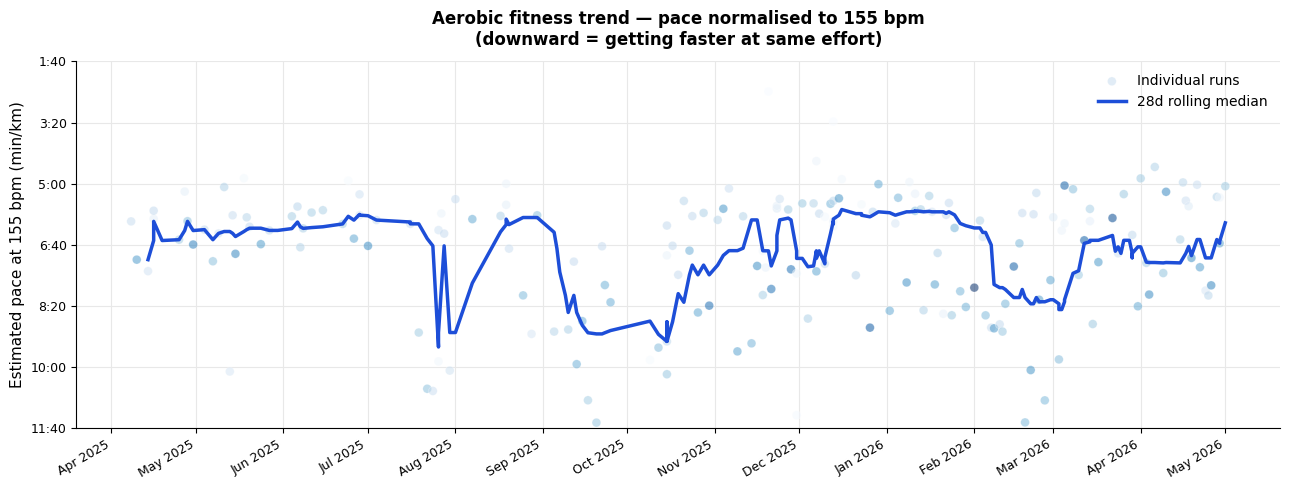

In [51]:
# ── Plot 8: Aerobic fitness trend — pace at a target HR zone ───────────────
# For each run, estimate what pace you'd run at TARGET_HR using:
#   adjusted_pace = pace_secs * (avg_hr / TARGET_HR)
# Smoothed 28-day rolling median reveals true fitness trend.

TARGET_HR = 155   # bpm — adjust to your aerobic threshold / Z2 ceiling

df_fit = df_all.dropna(subset=["avg_hr", "pace_secs"]).copy()
df_fit = df_fit[(df_fit["avg_hr"] > 100) & (df_fit["pace_secs"] > 0)]

# Normalise pace to what it would be at TARGET_HR
df_fit["norm_pace"] = df_fit["pace_secs"] * (df_fit["avg_hr"] / TARGET_HR)
df_fit = df_fit.sort_values("date").set_index("date")

# 28-day rolling median (more robust to outliers than mean)
rolling = df_fit["norm_pace"].rolling("28D", min_periods=3).median()

fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(df_fit.index, df_fit["norm_pace"],
           c=df_fit["distance_km"], cmap="Blues", s=40,
           alpha=0.55, edgecolors="white", lw=0.3, zorder=3, label="Individual runs")
ax.plot(rolling.index, rolling.values,
        color="#1D4ED8", lw=2.5, zorder=4, label="28d rolling median")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(secs_to_mss))
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=30, ha="right")
ax.set_ylabel(f"Estimated pace at {TARGET_HR} bpm (min/km)")
ax.set_title(
    f"Aerobic fitness trend — pace normalised to {TARGET_HR} bpm\n"
    "(downward = getting faster at same effort)",
    fontweight="bold", pad=12
)
ax.legend(frameon=False); ax.set_ylim(700, 100)
plt.tight_layout()
plt.show()

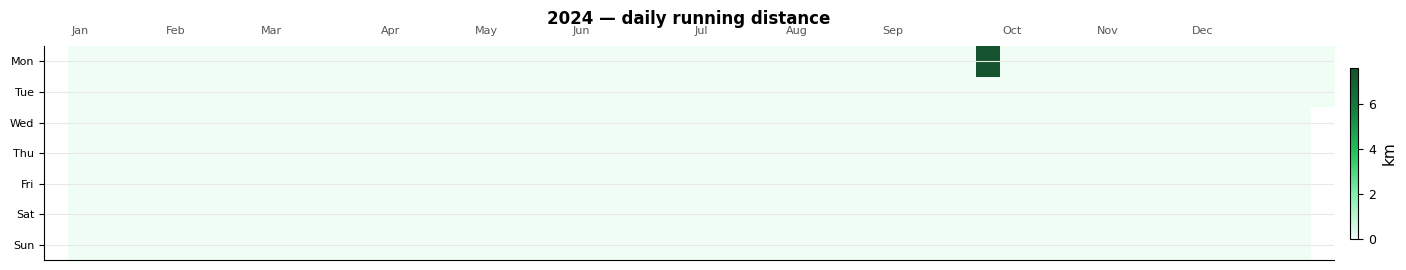

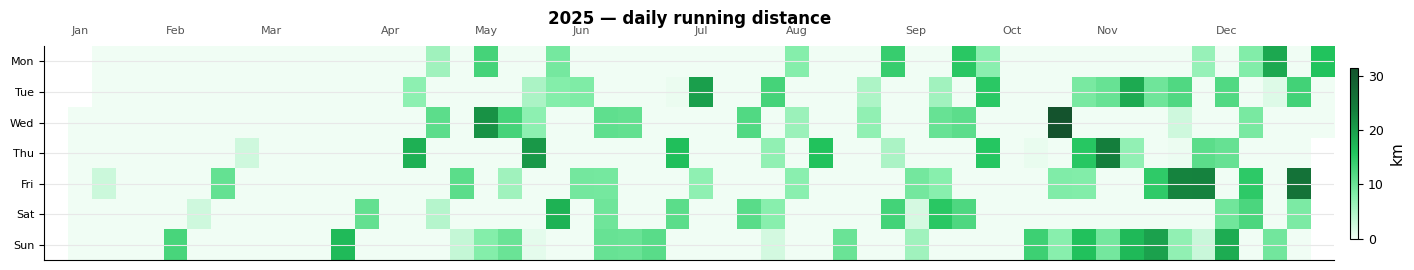

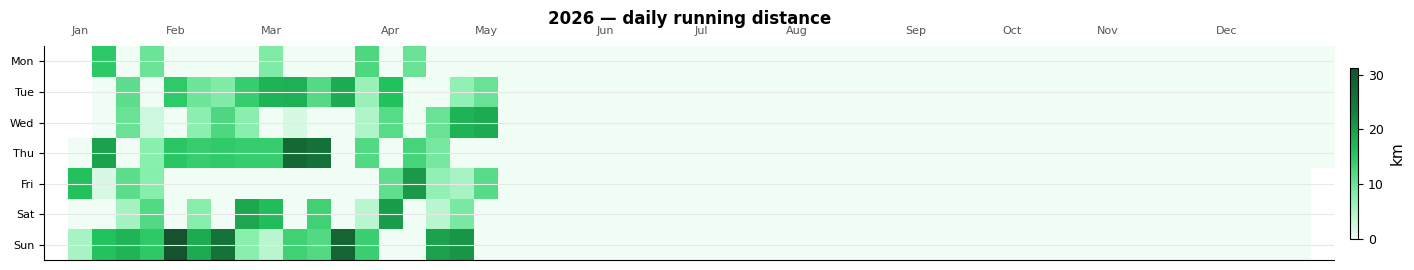

In [43]:
# ── Plot 9: GitHub-style activity calendar ─────────────────────────────────
df_cal = df_all[["date", "distance_km"]].copy()
df_cal = df_cal.groupby("date")["distance_km"].sum().reset_index()
df_cal["date"] = pd.to_datetime(df_cal["date"])

# Build the full year grid for each year in data
years = sorted(df_cal["date"].dt.year.unique())

for year in years:
    df_y = df_cal[df_cal["date"].dt.year == year].set_index("date")["distance_km"]
    all_days = pd.date_range(f"{year}-01-01", f"{year}-12-31")
    df_y = df_y.reindex(all_days, fill_value=0)

    # Grid: rows = weekday (0=Mon), cols = week number
    weeks = df_y.index.isocalendar().week.values.astype(int)
    # Handle week 53 / year boundary
    weeks = np.where((df_y.index.month == 1) & (weeks > 50), 0, weeks)
    weeks = np.where((df_y.index.month == 12) & (weeks == 1), 53, weeks)
    weekdays = df_y.index.weekday   # 0=Mon

    n_weeks = weeks.max() + 1
    grid = np.full((7, n_weeks), np.nan)
    for i, (w, d) in enumerate(zip(weeks, weekdays)):
        grid[d, w] = df_y.iloc[i]

    cmap_cal = LinearSegmentedColormap.from_list(
        "run", ["#f0fdf4", "#86efac", "#22c55e", "#15803d", "#14532d"]
    )

    fig, ax = plt.subplots(figsize=(16, 2.8))
    im = ax.imshow(grid, aspect="auto", cmap=cmap_cal,
                   vmin=0, vmax=max(df_y.max(), 1), interpolation="nearest")

    ax.set_yticks(range(7))
    ax.set_yticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], fontsize=8)
    ax.set_xticks([])

    # Month labels
    month_starts = {}
    for i, day in enumerate(all_days):
        if day.day == 1:
            month_starts[calendar.month_abbr[day.month]] = weeks[i]
    for month, w in month_starts.items():
        ax.text(w, -0.9, month, fontsize=8, ha="center", color="#555")

    plt.colorbar(im, ax=ax, orientation="vertical", label="km", shrink=0.8, pad=0.01)
    ax.set_title(f"{year} — daily running distance", fontweight="bold", pad=16)
    plt.tight_layout()
    plt.show()

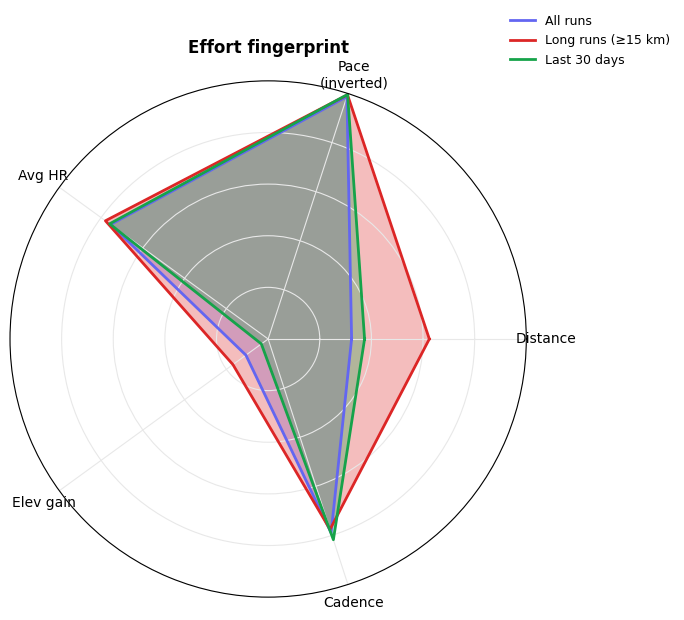

In [44]:
# ── Plot 10: Run effort fingerprint — radar chart ──────────────────────────
# Compare average profiles: all runs vs your longest 20% vs most recent 30 days

from matplotlib.patches import FancyArrowPatch

def radar(ax, values, color, label, alpha=0.3):
    N = len(values)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    vals   = values + [values[0]]
    angles += [angles[0]]
    ax.plot(angles, vals, color=color, lw=2, label=label)
    ax.fill(angles, vals, color=color, alpha=alpha)

metrics  = ["Distance", "Pace\n(inverted)", "Avg HR", "Elev gain", "Cadence"]
n = len(metrics)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()

def normalise_run(row, bounds):
    """Scale each metric to 0–1 given (min, max) bounds per metric."""
    vals = []
    for i, (lo, hi) in enumerate(bounds):
        raw = row[i]
        if np.isnan(raw) or hi == lo:
            vals.append(0.5)
        else:
            vals.append(np.clip((raw - lo) / (hi - lo), 0, 1))
    return vals

df_radar = df_all.dropna(subset=["pace_secs", "avg_hr"]).copy()
df_radar["elev_gain_m"] = df_radar["elev_gain_m"].fillna(0)
df_radar["avg_cadence"] = df_radar["avg_cadence"].fillna(df_radar["avg_cadence"].median())

# Invert pace so "higher = faster"
df_radar["pace_inv"] = df_radar["pace_secs"].max() - df_radar["pace_secs"]

cols = ["distance_km", "pace_inv", "avg_hr", "elev_gain_m", "avg_cadence"]
bounds = [(df_radar[c].min(), df_radar[c].max()) for c in cols]

def group_mean(subset):
    return [subset[c].mean() for c in cols]

all_mean    = normalise_run(group_mean(df_radar), bounds)
long_cutoff = df_radar["distance_km"].quantile(0.80)
long_mean   = normalise_run(group_mean(df_radar[df_radar["distance_km"] >= long_cutoff]), bounds)
recent_mask = df_radar["date"] >= (df_radar["date"].max() - pd.Timedelta(days=30))
recent_mean = normalise_run(group_mean(df_radar[recent_mask]), bounds)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
radar(ax, all_mean,    "#6366F1", "All runs")
radar(ax, long_mean,   "#DC2626", f"Long runs (≥{long_cutoff:.0f} km)")
radar(ax, recent_mean, "#16A34A", "Last 30 days")

ax.set_xticks(angles)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_yticklabels([])
ax.set_ylim(0, 1)
ax.set_title("Effort fingerprint", fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15), frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

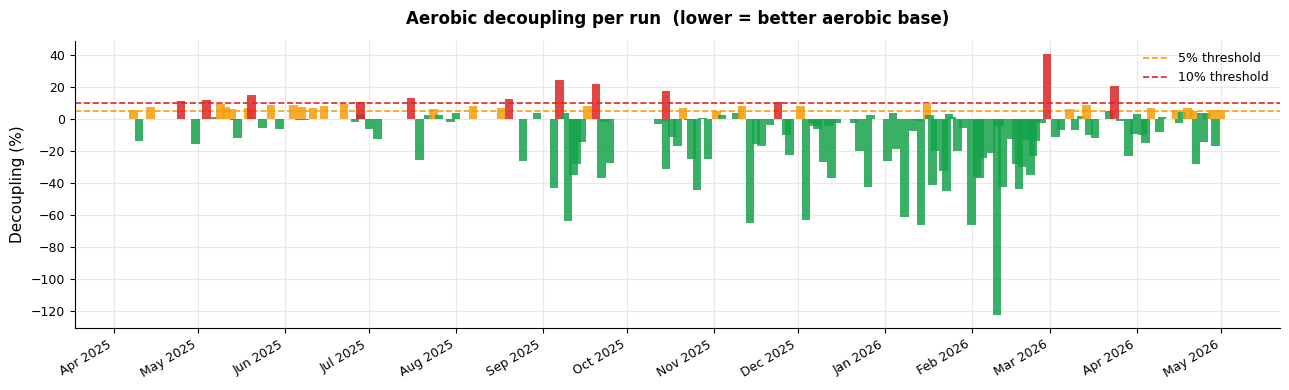

In [53]:
# ── Plot 11: Aerobic decoupling over time ──────────────────────────────────
# Decoupling = how much HR drifts relative to pace in the second half of a run
# Low decoupling (<5%) = good aerobic base
# High decoupling (>10%) = fatigue, heat, or poor base

def compute_decoupling(run_dict: dict) -> float | None:
    """
    Pa:HR decoupling.  Compares pace/HR efficiency in first vs second half.
    Returns % decoupling (positive = HR rose faster than pace changed).
    """
    df = run_dict["df"].copy()
    if "timestamp" not in df.columns or "heart_rate" not in df.columns:
        return None

    df = df.dropna(subset=["timestamp", "heart_rate"]).copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df = df.sort_values("timestamp")

    # Need speed; prefer enhanced_speed else compute from distance delta
    if "enhanced_speed" in df.columns:
        df["spd"] = pd.to_numeric(df["enhanced_speed"], errors="coerce")
    elif "speed" in df.columns:
        df["spd"] = pd.to_numeric(df["speed"], errors="coerce")
    else:
        dist = pd.to_numeric(df.get("distance", pd.Series(dtype=float)), errors="coerce")
        dt   = df["timestamp"].diff().dt.total_seconds()
        df["spd"] = dist.diff() / dt

    df = df.dropna(subset=["spd", "heart_rate"])
    df = df[(df["spd"] > 0.5) & (df["heart_rate"] > 80)]  # filter stops
    if len(df) < 20:
        return None

    mid = len(df) // 2
    def efficiency(half):
        return half["spd"].mean() / half["heart_rate"].mean()

    e1 = efficiency(df.iloc[:mid])
    e2 = efficiency(df.iloc[mid:])
    if e1 == 0:
        return None
    return (e2 - e1) / e1 * 100   # negative = HR rose, positive = HR dropped

decouple_rows = []
for run in analyzer.active_runs:
    if run["total_km"] < 5:   # skip very short runs
        continue
    dc = compute_decoupling(run)
    if dc is not None:
        decouple_rows.append({"date": run["date"], "decoupling": dc,
                              "distance_km": run["total_km"]})

df_dc = pd.DataFrame(decouple_rows).sort_values("date")

fig, ax = plt.subplots(figsize=(13, 4))
colors_dc = ["#DC2626" if v < -10 else "#F59E0B" if v < -5 else "#16A34A"
             for v in df_dc["decoupling"]]
ax.bar(df_dc["date"], -df_dc["decoupling"],   # flip sign: HR rise = positive bar
       color=colors_dc, width=3, alpha=0.85, zorder=3)
ax.axhline(5,  color="#F59E0B", lw=1.2, ls="--", label="5% threshold")
ax.axhline(10, color="#DC2626", lw=1.2, ls="--", label="10% threshold")

# rolling_dc = (-df_dc.set_index("date")["decoupling"]).rolling("28D", min_periods=3).mean()
# ax.plot(rolling_dc.index, rolling_dc.values, color="#1D4ED8", lw=2, label="28d avg")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=30, ha="right")
ax.set_ylabel("Decoupling (%)")
ax.set_title("Aerobic decoupling per run  (lower = better aerobic base)",
             fontweight="bold", pad=12)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

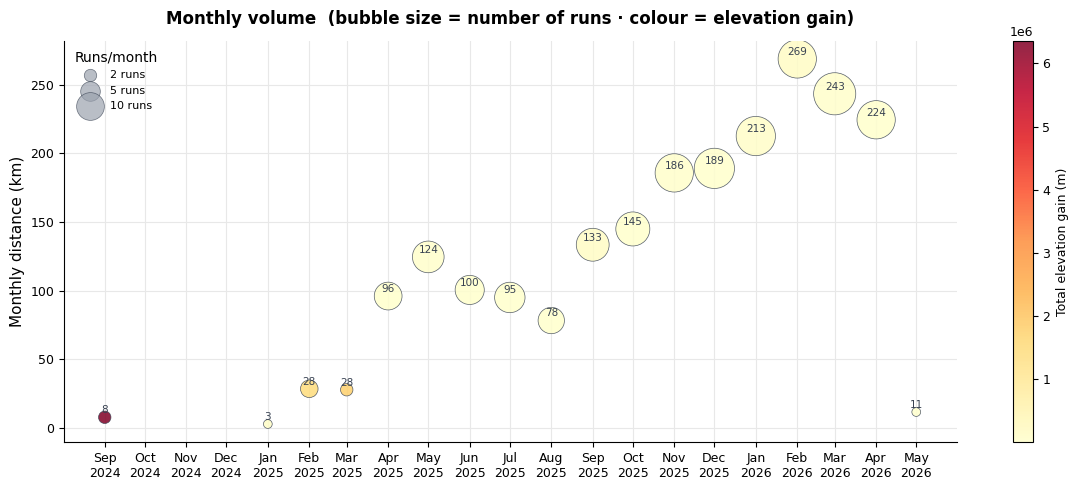

In [47]:
# ── Plot 13: Monthly distance vs elevation gain bubble chart ────────────────
df_mo = df_all.copy()
df_mo["month"] = df_mo["date"].dt.to_period("M")
monthly = (
    df_mo.groupby("month")
    .agg(
        total_km    =("distance_km", "sum"),
        total_elev  =("elev_gain_m", "sum"),
        n_runs      =("id", "count"),
    )
    .reset_index()
)
monthly["month_dt"] = monthly["month"].dt.to_timestamp()
monthly["total_elev"] = monthly["total_elev"].fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
sc = ax.scatter(
    monthly["month_dt"],
    monthly["total_km"],
    s=monthly["n_runs"] * 40,
    c=monthly["total_elev"],
    cmap="YlOrRd",
    alpha=0.85,
    edgecolors="#374151",
    lw=0.5,
    zorder=3,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Total elevation gain (m)", fontsize=9)

# Annotate each bubble with km
for _, row in monthly.iterrows():
    ax.text(row["month_dt"], row["total_km"] + 3,
            f"{row['total_km']:.0f}", ha="center", fontsize=7.5, color="#374151")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.set_ylabel("Monthly distance (km)")
ax.set_title(
    "Monthly volume  (bubble size = number of runs · colour = elevation gain)",
    fontweight="bold", pad=12
)
# Manual legend for bubble size
for n_runs in [2, 5, 10]:
    ax.scatter([], [], s=n_runs * 40, c="#9CA3AF", alpha=0.7,
               edgecolors="#374151", lw=0.5, label=f"{n_runs} runs")
ax.legend(title="Runs/month", frameon=False, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

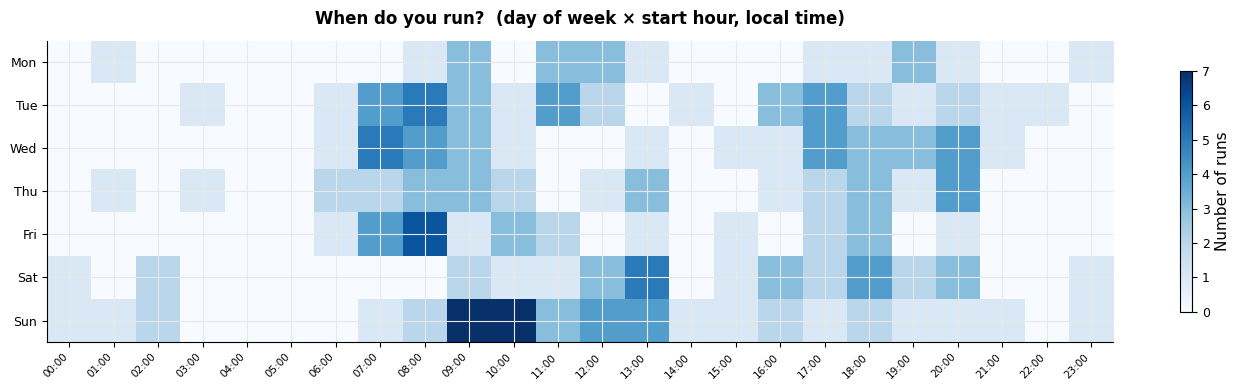

In [48]:
# ── Plot 14: When do you run? Day × hour heatmap ───────────────────────────
df_when = df_all.copy()
df_when["date"] = pd.to_datetime(df_when["date"])

# Pull actual start timestamps from the raw runs
start_times = []
for run in analyzer.active_runs:
    ts = run["df"]["timestamp"].dropna()
    if len(ts):
        t = pd.to_datetime(ts.iloc[0], utc=True).tz_convert("Europe/Madrid")
        start_times.append({"hour": t.hour, "dow": t.weekday(),
                            "distance_km": run["total_km"]})

df_when2 = pd.DataFrame(start_times)
pivot = df_when2.groupby(["dow", "hour"])["distance_km"].agg(["count", "mean"]).reset_index()
heat_count = pivot.pivot_table(index="dow", columns="hour", values="count", fill_value=0)
heat_count = heat_count.reindex(index=range(7), columns=range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(heat_count.values, aspect="auto", cmap="Blues",
               vmin=0, interpolation="nearest")
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, ha="right", fontsize=7.5)
ax.set_yticks(range(7))
ax.set_yticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
plt.colorbar(im, ax=ax, label="Number of runs", shrink=0.8)
ax.set_title("When do you run?  (day of week × start hour, local time)",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.show()